In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def detection_cost_grid(X, Y, omni_sensor_pos_x, omni_sensor_pos_y, dt1=0.0, dt2=50.0, param_lambda=1.0, param_beta=0.25):
    """
    Vectorized Elfes-like detection cost over a meshgrid (X, Y),
    for an omnidirectional sensor at (omni_sensor_pos_x, omni_sensor_pos_y).

    Returns:
        Z: same shape as X, detection cost in [0, 1]
    """
    R = np.sqrt((X - omni_sensor_pos_x)**2 + (Y - omni_sensor_pos_y)**2)  # range sensor->point

    Z = np.zeros_like(R, dtype=float)

    # Region 1: fully detected
    Z[R <= dt1] = 1.0
    mid = (R > dt1) & (R < dt2)

    raw = np.exp(-param_lambda * (R[mid] - dt1)**param_beta)
    raw_dt2 = np.exp(-param_lambda * (dt2 - dt1)**param_beta)

    # Normalize so Z(dt1)=1, Z(dt2)=0 continuously
    Z[mid] = (raw - raw_dt2) / (1.0 - raw_dt2)
    return Z


In [12]:
# Example: read bounds from your structure
# bounds = map_in['st']['size']              # [xmin, xmax, ymin, ymax]
bounds = [0, 100, 0, 100]
xmin, xmax, ymin, ymax = map(float, bounds)

# Sensor position (user-defined)
omni_sensor_pos_x = (bounds[1]-bounds[0])/2
omni_sensor_pos_y = (bounds[3]-bounds[2])/2
omni_sensor_range = (bounds[1]-bounds[0])

# Grid resolution (increase for smoother contours, decrease for speed)
N = 400
x = np.linspace(xmin, xmax, N)
y = np.linspace(ymin, ymax, N)
X, Y = np.meshgrid(x, y)

In [15]:
# Detection model parameters
dt1 = float(omni_sensor_range)/100
dt2 = float(omni_sensor_range)        # your omni sensor range cutoff
param_lambda = 0.5
param_beta = 0.25

Z = detection_cost_grid(X, Y, omni_sensor_pos_x, omni_sensor_pos_y, dt1=dt1, dt2=dt2,
                        param_lambda=param_lambda, param_beta=param_beta)

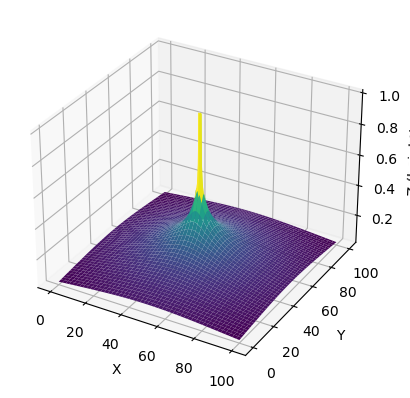

In [16]:
# %matplotlib widget  # in Jupyter (requires ipympl)
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, cmap="viridis", linewidth=0)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z (height)")

plt.show()